In [1]:
# 08_power_curves.ipynb — load, summarize, and plot power/FDR across n and rho.
from pathlib import Path
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 50)


In [2]:
def find_tables_dir():
    candidates = [Path("../results/tables"), Path("results/tables"), Path("../../results/tables")]
    for d in candidates:
        if d.exists():
            return d
    # create the default under parent repo root
    root = Path(".."); (root / "results" / "tables").mkdir(parents=True, exist_ok=True)
    return root / "results" / "tables"

TABLES = find_tables_dir()
files = sorted(TABLES.glob("power_*_p*.csv"))

print("TABLES =", TABLES.resolve())
print("Found", len(files), "power_* CSVs")
if files: print("e.g.", files[0].name)

# Load if present; keep df empty if none (so rest of cells won't crash)
df = pd.concat([pd.read_csv(f).assign(file=f.name) for f in files], ignore_index=True) if files else pd.DataFrame()
df.head()

TABLES = /workspaces/fdr-correlations/results/tables
Found 24 power_* CSVs
e.g. power_gaussian_p250_n120_rho0.5_b20_R20.csv


,model,x_model,p,n,rho,block,seed,R_bh_0.05,V_bh_0.05,S_bh_0.05,R_by_0.05,V_by_0.05,S_by_0.05,fdr_bh_0.05,power_bh_0.05,fdr_by_0.05,power_by_0.05,R_bh_0.1,V_bh_0.1,S_bh_0.1,R_by_0.1,V_by_0.1,S_by_0.1,fdr_bh_0.1,power_bh_0.1,...,R_lct_0.05,V_lct_0.05,S_lct_0.05,fdr_lct_0.05,power_lct_0.05,t_lct_0.1,R_lct_0.1,V_lct_0.1,S_lct_0.1,fdr_lct_0.1,power_lct_0.1,t_lctb_0.05_B100,R_lctb_0.05_B100,V_lctb_0.05_B100,S_lctb_0.05_B100,fdr_lctb_0.05_B100,power_lctb_0.05_B100,t_lctb_0.1_B100,R_lctb_0.1_B100,V_lctb_0.1_B100,S_lctb_0.1_B100,fdr_lctb_0.1_B100,power_lctb_0.1_B100,wall_time_s,file
0,gaussian,gaussian,250,120,0.5,20,0,105,3,102,32,0,32,0.028571,0.536842,0.000000,0.168421,122,7,115,66,1,65,0.057377,0.605263,...,154,7,147,0.045455,0.773684,3.474605,167,11,156,0.065868,0.821053,3.733697,152,6,146,0.039474,0.768421,3.485743,165,10,155,0.060606,0.815789,1.504108,power_gaussian_p250_n120_rho0.5_b20_R20.csv
1,gaussian,gaussian,250,120,0.5,20,1,99,4,95,42,0,42,0.040404,0.500000,0.000000,0.221053,130,11,119,54,0,54,0.084615,0.626316,...,137,5,132,0.036496,0.694737,3.484732,156,13,143,0.083333,0.752632,3.770652,136,4,132,0.029412,0.694737,3.538876,152,11,141,0.072368,0.742105,1.395475,power_gaussian_p250_n120_rho0.5_b20_R20.csv
2,gaussian,gaussian,250,120,0.5,20,2,124,5,119,51,0,51,0.040323,0.626316,0.000000,0.268421,151,13,138,74,1,73,0.086093,0.726316,...,169,7,162,0.041420,0.852632,3.449921,184,18,166,0.097826,0.873684,3.746809,165,5,160,0.030303,0.842105,3.483089,180,15,165,0.083333,0.868421,1.402158,power_gaussian_p250_n120_rho0.5_b20_R20.csv
3,gaussian,gaussian,250,120,0.5,20,3,176,7,169,118,1,117,0.039773,0.889474,0.008475,0.615789,200,23,177,137,2,135,0.115000,0.931579,...,188,8,180,0.042553,0.947368,3.400044,211,28,183,0.132701,0.963158,3.667210,187,7,180,0.037433,0.947368,3.453835,207,24,183,0.115942,0.963158,1.465019,power_gaussian_p250_n120_rho0.5_b20_R20.csv
4,gaussian,gaussian,250,120,0.5,20,4,94,3,91,42,1,41,0.031915,0.478947,0.023810,0.215789,136,17,119,48,1,47,0.125000,0.626316,...,147,7,140,0.047619,0.736842,3.506308,169,19,150,0.112426,0.789474,3.754856,145,6,139,0.041379,0.731579,3.524723,166,18,148,0.108434,0.778947,1.609125,power_gaussian_p250_n120_rho0.5_b20_R20.csv


In [3]:
def melt_prefix(df, prefix):
    cols = [c for c in df.columns if isinstance(c, str) and c.startswith(prefix)]
    if not cols: 
        return pd.DataFrame()
    id_vars = [c for c in df.columns if c not in cols]
    long = df.melt(id_vars=id_vars, value_vars=cols, var_name="metric", value_name="val")
    return long

def parse_alpha(metric):
    m = re.search(r'_(0\.05|0\.10)', str(metric))
    return m.group(1) if m else None

def parse_B(metric):
    m = re.search(r'_B(\d+)', str(metric))
    return int(m.group(1)) if m else None

def label_method(metric):
    s = str(metric)
    if "_bh_"   in s: return "BH"
    if "_by_"   in s: return "BY"
    if "_lctb_" in s: return "LCT-B"
    if "_lct_"  in s: return "LCT-N"
    return "?"

def choose_lctb_rows(long_lctb, B_choice=None):
    """
    Pick which LCT-B (B) to visualize:
      - B_choice is an int: keep that B only (if present)
      - B_choice is None: choose the largest B within each (file, model, p, n, rho, alpha) group
    """
    if long_lctb.empty:
        return long_lctb
    if B_choice is not None:
        return long_lctb[long_lctb["B"] == int(B_choice)].copy()
    idx = (long_lctb
           .groupby(["file","model","p","n","rho","alpha"])["B"]
           .idxmax())
    return long_lctb.loc[idx].copy()

In [4]:
if df.empty:
    print("No power_* CSVs loaded — run scripts/run_power_curves.py first.")
else:
    # Power
    pwr_parts = []
    for pref in ["power_bh_", "power_by_", "power_lct_", "power_lctb_"]:
        L = melt_prefix(df, pref)
        if L.empty: 
            continue
        L["alpha"]  = L["metric"].apply(parse_alpha).fillna("-")
        L["B"]      = L["metric"].apply(parse_B)
        L["method"] = L["metric"].apply(label_method)
        pwr_parts.append(L.rename(columns={"val":"power"}))
    power_long = pd.concat(pwr_parts, ignore_index=True) if pwr_parts else pd.DataFrame()

    # If multiple B for LCT-B, choose one to display (largest by default)
    lctb = power_long[power_long["method"]=="LCT-B"]
    keep_lctb = choose_lctb_rows(lctb, B_choice=None)
    power_disp = pd.concat([
        power_long[power_long["method"]!="LCT-B"], 
        keep_lctb
    ], ignore_index=True)

    # FDR
    fdr_parts = []
    for pref in ["fdr_bh_", "fdr_by_", "fdr_lct_", "fdr_lctb_"]:
        L = melt_prefix(df, pref)
        if L.empty: 
            continue
        L["alpha"]  = L["metric"].apply(parse_alpha).fillna("-")
        L["B"]      = L["metric"].apply(parse_B)
        L["method"] = L["metric"].apply(label_method)
        fdr_parts.append(L.rename(columns={"val":"fdr"}))
    fdr_long = pd.concat(fdr_parts, ignore_index=True) if fdr_parts else pd.DataFrame()
    lctb_f = fdr_long[fdr_long["method"]=="LCT-B"]
    keep_lctb_f = choose_lctb_rows(lctb_f, B_choice=None)
    fdr_disp = pd.concat([
        fdr_long[fdr_long["method"]!="LCT-B"],
        keep_lctb_f
    ], ignore_index=True)

    # Aggregate
    def agg_mean_se(fr, ycol):
        if fr.empty: 
            return pd.DataFrame()
        return (fr.groupby(["file","model","p","n","rho","alpha","method"], as_index=False)[ycol]
                  .agg(mean="mean", se=lambda x: x.std(ddof=1)/np.sqrt(len(x))))
    agg_power = agg_mean_se(power_disp, "power")
    agg_fdr   = agg_mean_se(fdr_disp,   "fdr")

    display(agg_power.head())
    display(agg_fdr.head())

,file,model,p,n,rho,alpha,method,mean,se
0,power_gaussian_p250_n120_rho0.5_b20_R20.csv,gaussian,250,120,0.5,-,BH,0.785263,0.022591
1,power_gaussian_p250_n120_rho0.5_b20_R20.csv,gaussian,250,120,0.5,-,BY,0.512105,0.032793
2,power_gaussian_p250_n120_rho0.5_b20_R20.csv,gaussian,250,120,0.5,-,LCT-B,0.815789,NaN
3,power_gaussian_p250_n120_rho0.5_b20_R20.csv,gaussian,250,120,0.5,-,LCT-N,0.900263,0.014027
4,power_gaussian_p250_n120_rho0.5_b20_R20.csv,gaussian,250,120,0.5,0.05,BH,0.708947,0.027048


,file,model,p,n,rho,alpha,method,mean,se
0,power_gaussian_p250_n120_rho0.5_b20_R20.csv,gaussian,250,120,0.5,-,BH,0.097406,0.004754
1,power_gaussian_p250_n120_rho0.5_b20_R20.csv,gaussian,250,120,0.5,-,BY,0.010014,0.001674
2,power_gaussian_p250_n120_rho0.5_b20_R20.csv,gaussian,250,120,0.5,-,LCT-B,0.060606,NaN
3,power_gaussian_p250_n120_rho0.5_b20_R20.csv,gaussian,250,120,0.5,-,LCT-N,0.102577,0.005239
4,power_gaussian_p250_n120_rho0.5_b20_R20.csv,gaussian,250,120,0.5,0.05,BH,0.045090,0.003082


In [5]:
def nice_title(file):
    m = re.search(r'power_(\w+)_p(\d+)_n(\d+)_rho([0-9.]+)_b(\d+)_R(\d+)\.csv', file)
    # files contain one (n,rho); we’ll build titles ad-hoc below
    return file

def plot_power_vs_rho(model, p, n, alpha="0.05"):
    sub = agg_power[(agg_power["model"]==model)&(agg_power["p"]==p)&(agg_power["n"]==n)&(agg_power["alpha"]==alpha)]
    if sub.empty:
        print(f"No data for {model}, p={p}, n={n}, alpha={alpha}"); 
        return
    plt.figure(figsize=(6.5,3.0))
    for m in ["BH","BY","LCT-N","LCT-B"]:
        s = sub[sub["method"]==m].sort_values("rho")
        if s.empty: continue
        plt.errorbar(s["rho"], s["mean"], yerr=s["se"], marker="o", label=m)
    plt.ylim(0,1); plt.xlabel("rho"); plt.ylabel("power")
    plt.title(f"{model} | p={p} | n={n} — Power vs rho @ α={alpha}")
    plt.legend(); plt.tight_layout(); plt.show()

def plot_power_vs_n(model, p, rho, alpha="0.05"):
    sub = agg_power[(agg_power["model"]==model)&(agg_power["p"]==p)&(agg_power["rho"]==rho)&(agg_power["alpha"]==alpha)]
    if sub.empty:
        print(f"No data for {model}, p={p}, rho={rho}, alpha={alpha}"); 
        return
    plt.figure(figsize=(6.5,3.0))
    for m in ["BH","BY","LCT-N","LCT-B"]:
        s = sub[sub["method"]==m].sort_values("n")
        if s.empty: continue
        plt.errorbar(s["n"], s["mean"], yerr=s["se"], marker="o", label=m)
    plt.ylim(0,1); plt.xlabel("n"); plt.ylabel("power")
    plt.title(f"{model} | p={p} | rho={rho:.2f} — Power vs n @ α={alpha}")
    plt.legend(); plt.tight_layout(); plt.show()

def plot_fdr_vs_rho(model, p, n, alpha="0.05"):
    sub = agg_fdr[(agg_fdr["model"]==model)&(agg_fdr["p"]==p)&(agg_fdr["n"]==n)&(agg_fdr["alpha"]==alpha)]
    if sub.empty: 
        print(f"No FDR data for {model}, p={p}, n={n}, alpha={alpha}")
        return
    plt.figure(figsize=(6.5,3.0))
    for m in ["BH","BY","LCT-N","LCT-B"]:
        s = sub[sub["method"]==m].sort_values("rho")
        if s.empty: continue
        plt.errorbar(s["rho"], s["mean"], yerr=s["se"], marker="o", label=m)
    plt.xlabel("rho"); plt.ylabel("FDR"); plt.ylim(0,1)
    plt.title(f"{model} | p={p} | n={n} — FDR vs rho @ α={alpha}")
    plt.legend(); plt.tight_layout(); plt.show()

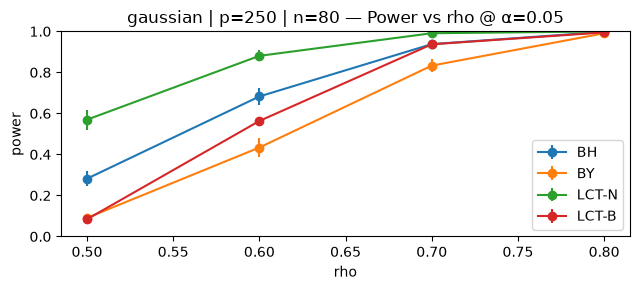

No data for gaussian, p=250, rho=0.3, alpha=0.05
No data for t, p=250, n=80, alpha=0.05
No data for t, p=250, rho=0.3, alpha=0.05
No data for laplace, p=250, n=80, alpha=0.05
No data for laplace, p=250, rho=0.3, alpha=0.05
No data for exp, p=250, n=80, alpha=0.05
No data for exp, p=250, rho=0.3, alpha=0.05


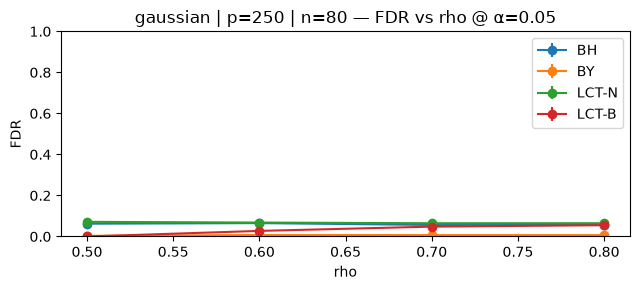

No FDR data for t, p=250, n=80, alpha=0.05
No FDR data for laplace, p=250, n=80, alpha=0.05
No FDR data for exp, p=250, n=80, alpha=0.05


In [6]:
# Examples — change these as needed
for model in ["gaussian","t","laplace","exp"]:
    plot_power_vs_rho(model, p=250, n=80, alpha="0.05")
    plot_power_vs_n(model,   p=250, rho=0.30, alpha="0.05")

# Optional: FDR sanity plots
for model in ["gaussian","t","laplace","exp"]:
    plot_fdr_vs_rho(model, p=250, n=80, alpha="0.05")

In [7]:
OUT = (TABLES.parent / "summary"); OUT.mkdir(parents=True, exist_ok=True)

if not agg_power.empty:
    out_p = OUT / "power_summary.csv"
    agg_power.to_csv(out_p, index=False)
    print("Wrote", out_p)

if not agg_fdr.empty:
    out_f = OUT / "fdr_summary.csv"
    agg_fdr.to_csv(out_f, index=False)
    print("Wrote", out_f)

Wrote ../results/summary/power_summary.csv
Wrote ../results/summary/fdr_summary.csv
